<a href="https://colab.research.google.com/github/sulucay01/DI725-assignment1/blob/dev/notebooks/03_modeling_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RoBERTa Baseline: Truncation Strategy Experiments

This notebook trains a **RoBERTa-base** classifier on the preprocessed customer conversation dataset and compares different truncation strategies for long conversations.

The main objective is to determine which truncation strategy preserves the most useful sentiment information before moving on to further modeling experiments.

## Imports

In [31]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import wandb

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed
)

## Experiment Configuration

In this section, we define the global experiment settings such as the random seed, model name, candidate maximum sequence lengths, and special tokens added during preprocessing.

In [33]:
SEED = 42
MODEL_NAME = "roberta-base"
MAX_LENGTH = 512
MAX_LENGTH_CANDIDATES = [128, 256, 384, 512]
PROJECT_NAME = "di725-baseline_models"

SPECIAL_TOKENS = ["[CUSTOMER]", "[AGENT]", "[EMAIL]", "[PHONE]", "[ID]"]

## Reproducibility

To make the experiments reproducible, we fix random seeds across Python, NumPy, PyTorch, and Hugging Face.
We also disable non-deterministic CuDNN behavior when available.

In [34]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Seed set to:", SEED)
print("CUDA available:", torch.cuda.is_available())

Seed set to: 42
CUDA available: True


## Load Processed Data

We load the processed train, validation, and test sets from the GitHub `dev` branch.
These files already contain the cleaned conversation text and encoded labels produced in the preprocessing notebook.

In [35]:
train_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/train_processed.csv")
val_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/val_processed.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/test_processed.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (773, 16)
Val shape: (194, 16)
Test shape: (30, 16)


## Dataset Sanity Checks

Before training, we verify that:
- required columns exist
- `clean_text` does not contain problematic missing values
- class distributions look consistent across splits

In [36]:
required_cols = ["conversation", "clean_text", "label", "customer_sentiment"]

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{name.upper()}")
    print("Missing required columns:", [c for c in required_cols if c not in df.columns])
    print("Null clean_text:", df["clean_text"].isna().sum())
    print("Empty clean_text:", (df["clean_text"].fillna("").str.strip() == "").sum())
    print("Label distribution:")
    print(df["customer_sentiment"].value_counts(normalize=True))


TRAIN
Missing required columns: []
Null clean_text: 0
Empty clean_text: 0
Label distribution:
customer_sentiment
neutral     0.560155
negative    0.421734
positive    0.018111
Name: proportion, dtype: float64

VAL
Missing required columns: []
Null clean_text: 0
Empty clean_text: 0
Label distribution:
customer_sentiment
neutral     0.561856
negative    0.422680
positive    0.015464
Name: proportion, dtype: float64

TEST
Missing required columns: []
Null clean_text: 0
Empty clean_text: 0
Label distribution:
customer_sentiment
negative    0.333333
neutral     0.333333
positive    0.333333
Name: proportion, dtype: float64


## Special Token Usage

During preprocessing, sensitive entities and speaker roles were replaced with special placeholders such as `[EMAIL]`, `[PHONE]`, `[ID]`, `[CUSTOMER]`, and `[AGENT]`.

Before training, we inspect how often these tokens appear in each split. This helps us verify that the preprocessing pipeline worked as intended and that these placeholders are present in meaningful proportions.

In [37]:
SPECIAL_TOKENS = ["[EMAIL]", "[PHONE]", "[ID]", "[CUSTOMER]", "[AGENT]"]

def token_statistics(df, text_col="clean_text", split_name="train"):
    text_series = df[text_col].fillna("").astype(str)

    print(f"\n===== {split_name.upper()} TOKEN STATISTICS =====")

    for token in SPECIAL_TOKENS:
        contains_mask = text_series.str.contains(token, regex=False)
        count_rows = contains_mask.sum()
        pct_rows = 100 * count_rows / len(df)

        counts_per_row = text_series.apply(lambda x: x.count(token))

        total_occ = counts_per_row.sum()
        mean_per_row = counts_per_row.mean()
        mean_when_present = counts_per_row[contains_mask].mean() if count_rows > 0 else 0
        max_per_row = counts_per_row.max()

        print(f"\n{token}")
        print(f"  rows_with_token:     {count_rows} ({pct_rows:.2f}%)")
        print(f"  total_occurrences:   {total_occ}")
        print(f"  mean_per_row:        {mean_per_row:.2f}")
        print(f"  mean_when_present:   {mean_when_present:.2f}")
        print(f"  max_in_single_row:   {max_per_row}")

token_statistics(train_df, "clean_text", "train")
token_statistics(val_df, "clean_text", "val")
token_statistics(test_df, "clean_text", "test")


===== TRAIN TOKEN STATISTICS =====

[EMAIL]
  rows_with_token:     255 (32.99%)
  total_occurrences:   294
  mean_per_row:        0.38
  mean_when_present:   1.15
  max_in_single_row:   5

[PHONE]
  rows_with_token:     64 (8.28%)
  total_occurrences:   73
  mean_per_row:        0.09
  mean_when_present:   1.14
  max_in_single_row:   3

[ID]
  rows_with_token:     355 (45.92%)
  total_occurrences:   416
  mean_per_row:        0.54
  mean_when_present:   1.17
  max_in_single_row:   8

[CUSTOMER]
  rows_with_token:     773 (100.00%)
  total_occurrences:   6238
  mean_per_row:        8.07
  mean_when_present:   8.07
  max_in_single_row:   17

[AGENT]
  rows_with_token:     773 (100.00%)
  total_occurrences:   7007
  mean_per_row:        9.06
  mean_when_present:   9.06
  max_in_single_row:   16

===== VAL TOKEN STATISTICS =====

[EMAIL]
  rows_with_token:     64 (32.99%)
  total_occurrences:   82
  mean_per_row:        0.42
  mean_when_present:   1.28
  max_in_single_row:   4

[PHONE]
  

## Raw vs Cleaned Text Length Comparison

Next, we compare the raw conversation text with the cleaned version.

This step helps us understand how much text was removed or simplified during preprocessing. Since transformer models are sensitive to sequence length, this reduction can have a direct effect on how much conversational content fits into the model input window.

In [38]:
RAW_COL = "conversation"
CLEAN_COL = "clean_text"

for df in [train_df, val_df, test_df]:
    df[RAW_COL] = df[RAW_COL].fillna("").astype(str)
    df[CLEAN_COL] = df[CLEAN_COL].fillna("").astype(str)

def compare_char_lengths(df, raw_col=RAW_COL, clean_col=CLEAN_COL, split_name="train"):
    temp = df.copy()

    temp["raw_char_len"] = temp[raw_col].str.len()
    temp["clean_char_len"] = temp[clean_col].str.len()
    temp["char_diff"] = temp["raw_char_len"] - temp["clean_char_len"]
    temp["char_reduction_pct"] = np.where(
        temp["raw_char_len"] > 0,
        100 * temp["char_diff"] / temp["raw_char_len"],
        0
    )

    print(f"\n===== {split_name.upper()} CHARACTER LENGTH COMPARISON =====")
    print("Raw mean:        ", round(temp["raw_char_len"].mean(), 2))
    print("Clean mean:      ", round(temp["clean_char_len"].mean(), 2))
    print("Mean reduction:  ", round(temp["char_diff"].mean(), 2))
    print("Mean reduction %:", round(temp["char_reduction_pct"].mean(), 2))

    print("\nPercentiles of reduction %")
    print(temp["char_reduction_pct"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

    return temp

train_char_cmp = compare_char_lengths(train_df, split_name="train")
val_char_cmp = compare_char_lengths(val_df, split_name="val")
test_char_cmp = compare_char_lengths(test_df, split_name="test")


===== TRAIN CHARACTER LENGTH COMPARISON =====
Raw mean:         2130.08
Clean mean:       2122.86
Mean reduction:   7.22
Mean reduction %: 0.34

Percentiles of reduction %
0.25    0.000000
0.50    0.286738
0.75    0.536769
0.90    0.847337
0.95    1.071453
0.99    1.604934
Name: char_reduction_pct, dtype: float64

===== VAL CHARACTER LENGTH COMPARISON =====
Raw mean:         2158.35
Clean mean:       2150.7
Mean reduction:   7.65
Mean reduction %: 0.34

Percentiles of reduction %
0.25    0.056269
0.50    0.276847
0.75    0.541928
0.90    0.869260
0.95    1.118005
0.99    1.572756
Name: char_reduction_pct, dtype: float64

===== TEST CHARACTER LENGTH COMPARISON =====
Raw mean:         2178.57
Clean mean:       2171.27
Mean reduction:   7.3
Mean reduction %: 0.3

Percentiles of reduction %
0.25    0.000000
0.50    0.247685
0.75    0.473613
0.90    0.603684
0.95    0.863600
0.99    1.390460
Name: char_reduction_pct, dtype: float64


## Tokenizer Setup with Custom Special Tokens

We use the `roberta-base` tokenizer and explicitly add the preprocessing placeholders as additional special tokens.

This is important because otherwise tokens such as `[CUSTOMER]` or `[EMAIL]` may be broken into several subword pieces. By registering them as special tokens, we ensure that the model sees them as single semantic units.

In [40]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
num_added = tokenizer.add_special_tokens({"additional_special_tokens": SPECIAL_TOKENS})

print("Added tokens:", num_added)

Added tokens: 5


## Token Length Comparison

After setting up the tokenizer, we compare tokenized sequence lengths for raw and cleaned text.

This gives a more realistic measure than character counts, because the transformer model operates on tokens rather than characters. The goal is to check whether preprocessing reduces token length enough to improve input efficiency.

In [41]:
base_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

special_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
special_tokenizer.add_special_tokens({"additional_special_tokens": SPECIAL_TOKENS})

def get_token_lengths(texts, tokenizer):
    lengths = []
    for text in texts:
        enc = tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )
        lengths.append(len(enc["input_ids"]))
    return lengths

def compare_token_lengths_with_special_tokenizer(df, raw_col="conversation", clean_col="clean_text", split_name="train"):
    raw_texts = df[raw_col].fillna("").astype(str).tolist()
    clean_texts = df[clean_col].fillna("").astype(str).tolist()

    raw_lengths = get_token_lengths(raw_texts, base_tokenizer)
    clean_lengths = get_token_lengths(clean_texts, special_tokenizer)

    diff = np.array(raw_lengths) - np.array(clean_lengths)
    reduction_pct = np.where(np.array(raw_lengths) > 0, 100 * diff / np.array(raw_lengths), 0)

    print(f"\n===== {split_name.upper()} TOKEN LENGTH COMPARISON =====")
    print("Raw mean:        ", round(np.mean(raw_lengths), 2))
    print("Clean mean:      ", round(np.mean(clean_lengths), 2))
    print("Mean reduction:  ", round(np.mean(diff), 2))
    print("Mean reduction %:", round(np.mean(reduction_pct), 2))

compare_token_lengths_with_special_tokenizer(train_df, split_name="train")
compare_token_lengths_with_special_tokenizer(val_df, split_name="val")
compare_token_lengths_with_special_tokenizer(test_df, split_name="test")

Token indices sequence length is longer than the specified maximum sequence length for this model (554 > 512). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (516 > 512). Running this sequence through the model will result in indexing errors



===== TRAIN TOKEN LENGTH COMPARISON =====
Raw mean:         514.32
Clean mean:       476.27
Mean reduction:   38.06
Mean reduction %: 7.5

===== VAL TOKEN LENGTH COMPARISON =====
Raw mean:         521.86
Clean mean:       482.78
Mean reduction:   39.08
Mean reduction %: 7.6

===== TEST TOKEN LENGTH COMPARISON =====
Raw mean:         528.6
Clean mean:       489.73
Mean reduction:   38.87
Mean reduction %: 7.5


## Maximum Length Analysis

Since RoBERTa has a limited input size, we need to choose an appropriate maximum sequence length.

In this section, we measure the token length distribution of the cleaned conversations and estimate how many samples would be truncated under different candidate values: 128, 256, 384, and 512.

This analysis helps justify the final choice of `max_length`.

In [42]:
def summarize_lengths(lengths, split_name):
    arr = np.array(lengths)

    print(f"\n===== {split_name.upper()} TOKEN LENGTH SUMMARY =====")
    print(f"count:   {len(arr)}")
    print(f"min:     {arr.min()}")
    print(f"mean:    {arr.mean():.2f}")
    print(f"median:  {np.median(arr):.2f}")
    print(f"p90:     {np.percentile(arr, 90):.2f}")
    print(f"p95:     {np.percentile(arr, 95):.2f}")
    print(f"p99:     {np.percentile(arr, 99):.2f}")
    print(f"max:     {arr.max()}")

def truncation_report(lengths, split_name, candidates=MAX_LENGTH_CANDIDATES):
    arr = np.array(lengths)

    print(f"\n===== {split_name.upper()} TRUNCATION REPORT =====")
    for max_len in candidates:
        truncated = (arr > max_len).sum()
        rate = truncated / len(arr) * 100
        print(f"max_length={max_len:<3} -> truncated: {truncated:>5} / {len(arr)} ({rate:.2f}%)")

train_lengths = get_token_lengths(train_df["clean_text"].tolist(), tokenizer)
val_lengths = get_token_lengths(val_df["clean_text"].tolist(), tokenizer)
test_lengths = get_token_lengths(test_df["clean_text"].tolist(), tokenizer)

summarize_lengths(train_lengths, "train")
summarize_lengths(val_lengths, "val")
summarize_lengths(test_lengths, "test")

truncation_report(train_lengths, "train")
truncation_report(val_lengths, "val")
truncation_report(test_lengths, "test")

Token indices sequence length is longer than the specified maximum sequence length for this model (516 > 512). Running this sequence through the model will result in indexing errors



===== TRAIN TOKEN LENGTH SUMMARY =====
count:   773
min:     170
mean:    476.27
median:  460.00
p90:     628.60
p95:     687.40
p99:     830.00
max:     1263

===== VAL TOKEN LENGTH SUMMARY =====
count:   194
min:     227
mean:    482.78
median:  447.00
p90:     660.00
p95:     757.15
p99:     858.82
max:     1017

===== TEST TOKEN LENGTH SUMMARY =====
count:   30
min:     256
mean:    489.73
median:  466.00
p90:     639.70
p95:     715.85
p99:     1087.53
max:     1216

===== TRAIN TRUNCATION REPORT =====
max_length=128 -> truncated:   773 / 773 (100.00%)
max_length=256 -> truncated:   766 / 773 (99.09%)
max_length=384 -> truncated:   596 / 773 (77.10%)
max_length=512 -> truncated:   250 / 773 (32.34%)

===== VAL TRUNCATION REPORT =====
max_length=128 -> truncated:   194 / 194 (100.00%)
max_length=256 -> truncated:   193 / 194 (99.48%)
max_length=384 -> truncated:   158 / 194 (81.44%)
max_length=512 -> truncated:    60 / 194 (30.93%)

===== TEST TRUNCATION REPORT =====
max_length=12

## Token Length Distribution

To complement the numerical summary, we visualize the token length distribution on the training set.

This plot provides a clearer view of how concentrated the sequence lengths are and how many outlier conversations may be substantially longer than the selected maximum length.

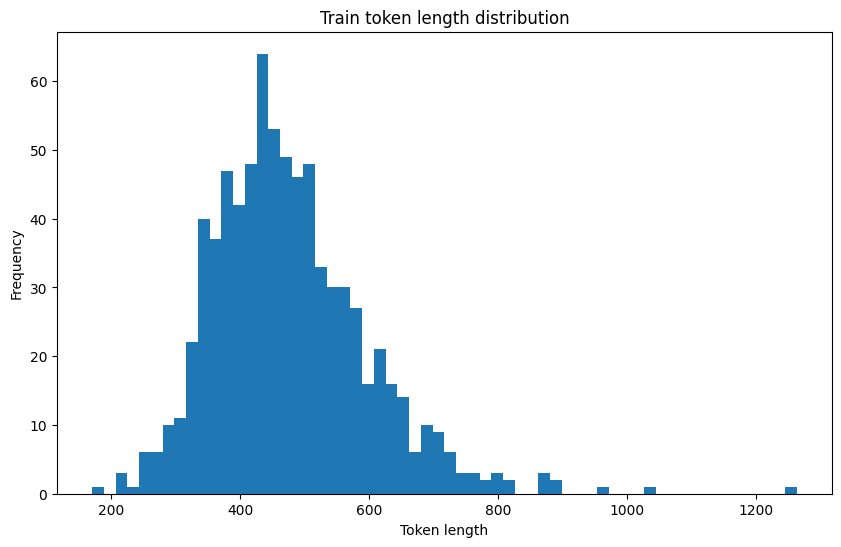

In [43]:
plt.figure(figsize=(10, 6))
plt.hist(train_lengths, bins=60)
plt.xlabel("Token length")
plt.ylabel("Frequency")
plt.title("Train token length distribution")
plt.show()

## Truncation Strategies

Because some conversations exceed the model's maximum length, we need a principled way to shorten them.

We compare three truncation strategies:

- **Head**: keep the beginning of the conversation
- **Tail**: keep the end of the conversation
- **Head-Tail**: keep part of the beginning and part of the end

This comparison is especially important for sentiment classification, because emotionally informative content may appear early, late, or in both parts of the interaction.

In [44]:
TRUNCATION_STRATEGY = "head"

def truncate_text(text, tokenizer, max_length, strategy="head"):
    if not isinstance(text, str):
        text = ""

    token_ids = tokenizer.encode(text, add_special_tokens=False)
    token_budget = max_length - 2  # reserve space for <s> and </s>

    if len(token_ids) <= token_budget:
        return text

    if strategy == "head":
        kept_ids = token_ids[:token_budget]
    elif strategy == "tail":
        kept_ids = token_ids[-token_budget:]
    elif strategy == "head_tail":
        head_size = token_budget // 2
        tail_size = token_budget - head_size
        kept_ids = token_ids[:head_size] + token_ids[-tail_size:]
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    return tokenizer.decode(
        kept_ids,
        skip_special_tokens=False,
        clean_up_tokenization_spaces=True
    )

def apply_truncation(df, strategy, tokenizer, max_length):
    out = df.copy()
    out["model_text"] = out["clean_text"].apply(
        lambda x: truncate_text(x, tokenizer, max_length, strategy=strategy)
    )
    return out

## Baseline Experiment: Head Truncation

We start with the **head-only** strategy as the initial baseline.

The purpose of this first run is to establish a reference point before testing tail-only and head-tail truncation. After this baseline is complete, we will compare all strategies using the same model and training configuration.

In [45]:
train_exp = apply_truncation(train_df, TRUNCATION_STRATEGY, tokenizer, MAX_LENGTH)
val_exp = apply_truncation(val_df, TRUNCATION_STRATEGY, tokenizer, MAX_LENGTH)
test_exp = apply_truncation(test_df, TRUNCATION_STRATEGY, tokenizer, MAX_LENGTH)

print(train_exp[["clean_text", "model_text"]].head(2))

                                          clean_text  \
0  [AGENT] Hello, thank you for contacting BrownB...   
1  [CUSTOMER] Hi, I need help with returning a to...   

                                          model_text  
0  [AGENT] Hello, thank you for contacting BrownB...  
1  [CUSTOMER] Hi, I need help with returning a to...  


## Sanity Check After Truncation

Before tokenizing the final model inputs, we verify that the manually truncated text sequences now fit within the target token limit.

This confirms that the truncation logic is working correctly.

In [46]:
train_model_lengths = get_token_lengths(train_exp["model_text"].tolist(), tokenizer)
val_model_lengths = get_token_lengths(val_exp["model_text"].tolist(), tokenizer)
test_model_lengths = get_token_lengths(test_exp["model_text"].tolist(), tokenizer)

print("Train max length after truncation:", max(train_model_lengths))
print("Val max length after truncation:", max(val_model_lengths))
print("Test max length after truncation:", max(test_model_lengths))

Train max length after truncation: 512
Val max length after truncation: 512
Test max length after truncation: 512


## Convert to Hugging Face Datasets

To train the model using the Hugging Face `Trainer`, we convert the processed pandas DataFrames into `Dataset` objects.

At this stage, we keep only the text used by the model (`model_text`) and the encoded target label.

In [47]:
train_hf = Dataset.from_pandas(train_exp[["model_text", "label"]], preserve_index=False)
val_hf = Dataset.from_pandas(val_exp[["model_text", "label"]], preserve_index=False)
test_hf = Dataset.from_pandas(test_exp[["model_text", "label"]], preserve_index=False)

print(train_hf)
print(val_hf)
print(test_hf)

Dataset({
    features: ['model_text', 'label'],
    num_rows: 773
})
Dataset({
    features: ['model_text', 'label'],
    num_rows: 194
})
Dataset({
    features: ['model_text', 'label'],
    num_rows: 30
})


## Tokenization

We now tokenize the truncated text using the final RoBERTa tokenizer with the added special tokens.

Although we already manually truncated the text into `model_text`, we still keep `truncation=True` during tokenization as a safety check. In practice, the manual truncation step should already ensure that the sequences fit within the selected maximum length.

In [48]:
def tokenize_batch(batch):
    return tokenizer(
        batch["model_text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )

train_hf = train_hf.map(tokenize_batch, batched=True)
val_hf = val_hf.map(tokenize_batch, batched=True)
test_hf = test_hf.map(tokenize_batch, batched=True)

train_hf = train_hf.rename_column("label", "labels")
val_hf = val_hf.rename_column("label", "labels")
test_hf = test_hf.rename_column("label", "labels")

columns_to_keep = ["input_ids", "attention_mask", "labels"]

train_hf.set_format(type="torch", columns=columns_to_keep)
val_hf.set_format(type="torch", columns=columns_to_keep)
test_hf.set_format(type="torch", columns=columns_to_keep)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_hf[0].keys())
print(len(train_hf[0]["input_ids"]), len(train_hf[0]["attention_mask"]))
print(train_hf[0]["labels"])

Map:   0%|          | 0/773 [00:00<?, ? examples/s]

Map:   0%|          | 0/194 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

dict_keys(['labels', 'input_ids', 'attention_mask'])
512 512
tensor(0)


## Label Mapping and Evaluation Metrics

Before training, we recover the sentiment class names in the correct encoded label order.

For evaluation, we report:
- accuracy
- macro F1
- weighted F1
- per-class precision, recall, and F1

Macro F1 is especially important here because it gives equal importance to all classes, which is useful when the dataset is imbalanced.

In [49]:
label_map_df = (
    train_df[["customer_sentiment", "label"]]
    .drop_duplicates()
    .sort_values("label")
)

label_names = label_map_df["customer_sentiment"].tolist()
num_labels = len(label_names)

print("Num labels:", num_labels)
print("Label names in encoded order:", label_names)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )

    metrics = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

    for i in range(len(precision)):
        metrics[f"precision_class_{i}"] = precision[i]
        metrics[f"recall_class_{i}"] = recall[i]
        metrics[f"f1_class_{i}"] = f1[i]

    return metrics

Num labels: 3
Label names in encoded order: ['negative', 'neutral', 'positive']


## Experiment Tracking with Weights & Biases

We use Weights & Biases (W&B) to track hyperparameters, training curves, and evaluation metrics for each truncation strategy.

Each experiment will use a separate run name so that the results can be compared easily later.

In [50]:
RUN_NAME = f"roberta_{TRUNCATION_STRATEGY}_{MAX_LENGTH}_seed{SEED}"

wandb.login()

wandb.init(
    project=PROJECT_NAME,
    name=RUN_NAME,
    config={
        "seed": SEED,
        "model_name": MODEL_NAME,
        "max_length": MAX_LENGTH,
        "truncation_strategy": TRUNCATION_STRATEGY,
        "text_column": "clean_text",
        "model_text_column": "model_text",
        "num_labels": num_labels,
        "train_size": len(train_df),
        "val_size": len(val_df),
        "test_size": len(test_df),
    }
)

## Model Initialization

We use `roberta-base` as the baseline transformer model for sequence classification.

Because we added custom special tokens to the tokenizer, we also resize the model's token embedding matrix so that these new tokens can be learned during training.

In [51]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

model.resize_token_embeddings(len(tokenizer))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Embedding(50270, 768, padding_idx=1)

## Training Configuration

All truncation strategies are trained with the same hyperparameters so that the comparison remains fair.

We evaluate once per epoch and keep the best checkpoint based on validation macro F1.

In [52]:
training_args = TrainingArguments(
    output_dir=f"./outputs/{RUN_NAME}",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="wandb",
    run_name=RUN_NAME,
    fp16=torch.cuda.is_available(),
    seed=SEED
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


## Trainer Setup

We use the Hugging Face `Trainer` API to manage the training and evaluation loop.

The trainer receives:
- the model
- training arguments
- train and validation datasets
- the dynamic padding collator
- the custom metric function

In [53]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Run name:", RUN_NAME)
print("Train size:", len(train_hf))
print("Val size:", len(val_hf))
print("Test size:", len(test_hf))
print("Tokenizer size:", len(tokenizer))
print("Model vocab resized:", model.get_input_embeddings().weight.shape[0])
print("Max train sequence length after truncation:", max(train_model_lengths))

Run name: roberta_head_512_seed42
Train size: 773
Val size: 194
Test size: 30
Tokenizer size: 50270
Model vocab resized: 50270
Max train sequence length after truncation: 512


## Train the Head-Truncation Baseline

We now train the first baseline model using the head-only truncation strategy.

After training, we evaluate the best checkpoint on the validation set and inspect the resulting metrics.

In [54]:
train_result = trainer.train()
val_metrics = trainer.evaluate()

print("\nValidation metrics:")
print(val_metrics)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision Class 0,Recall Class 0,F1 Class 0,Precision Class 1,Recall Class 1,F1 Class 1,Precision Class 2,Recall Class 2,F1 Class 2
1,0.476001,0.837782,0.768041,0.496292,0.744498,0.976190,0.500000,0.661290,0.710526,0.990826,0.827586,0.000000,0.000000,0.000000
2,0.363276,0.352671,0.902062,0.604822,0.894567,0.945946,0.853659,0.897436,0.875000,0.963303,0.917031,0.000000,0.000000,0.000000
3,0.217162,0.422494,0.896907,0.601708,0.889740,0.911392,0.878049,0.894410,0.886957,0.935780,0.910714,0.000000,0.000000,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Validation metrics:
{'eval_loss': 0.35282379388809204, 'eval_accuracy': 0.9020618556701031, 'eval_macro_f1': 0.6048221550404956, 'eval_weighted_f1': 0.8945673993168705, 'eval_precision_class_0': 0.9459459459459459, 'eval_recall_class_0': 0.8536585365853658, 'eval_f1_class_0': 0.8974358974358975, 'eval_precision_class_1': 0.875, 'eval_recall_class_1': 0.963302752293578, 'eval_f1_class_1': 0.9170305676855895, 'eval_precision_class_2': 0.0, 'eval_recall_class_2': 0.0, 'eval_f1_class_2': 0.0, 'eval_runtime': 0.3952, 'eval_samples_per_second': 490.829, 'eval_steps_per_second': 32.891, 'epoch': 3.0}


## Detailed Evaluation

To better understand model behavior, we define a helper function that evaluates a dataset split and prints:
- a classification report
- a confusion matrix
- split-level summary metrics

We apply this function to the train, validation, and test sets.

In [55]:
def evaluate_split(trainer, dataset, split_name, label_names):
    predictions = trainer.predict(dataset)
    logits = predictions.predictions
    y_true = predictions.label_ids
    y_pred = np.argmax(logits, axis=1)

    print(f"\n===== {split_name.upper()} CLASSIFICATION REPORT =====")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n===== {split_name.upper()} CONFUSION MATRIX =====")
    print(cm)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )

    metrics = {
        f"{split_name}_accuracy": accuracy_score(y_true, y_pred),
        f"{split_name}_macro_f1": f1_score(y_true, y_pred, average="macro"),
        f"{split_name}_weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    for i in range(len(precision)):
        metrics[f"{split_name}_precision_class_{i}"] = precision[i]
        metrics[f"{split_name}_recall_class_{i}"] = recall[i]
        metrics[f"{split_name}_f1_class_{i}"] = f1[i]

    wandb.log(metrics)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "logits": logits,
        "confusion_matrix": cm,
        "metrics": metrics
    }

## Evaluate the Baseline on All Splits

We now evaluate the trained baseline model on the train, validation, and test sets.

This helps us assess both generalization performance and possible overfitting.

In [56]:
train_results = evaluate_split(trainer, train_hf, "train", label_names)
val_results = evaluate_split(trainer, val_hf, "val", label_names)
test_results = evaluate_split(trainer, test_hf, "test", label_names)

head_results = {
    "run_name": RUN_NAME,
    "strategy": "head",
    "train_results": train_results,
    "val_results": val_results,
    "test_results": test_results
}

wandb.finish()


===== TRAIN CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       0.97      0.91      0.94       326
     neutral       0.91      0.98      0.94       433
    positive       0.00      0.00      0.00        14

    accuracy                           0.93       773
   macro avg       0.62      0.63      0.63       773
weighted avg       0.92      0.93      0.92       773


===== TRAIN CONFUSION MATRIX =====
[[296  30   0]
 [ 10 423   0]
 [  0  14   0]]



===== VAL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       0.95      0.85      0.90        82
     neutral       0.88      0.96      0.92       109
    positive       0.00      0.00      0.00         3

    accuracy                           0.90       194
   macro avg       0.61      0.61      0.60       194
weighted avg       0.89      0.90      0.89       194


===== VAL CONFUSION MATRIX =====
[[ 70  12   0]
 [  4 105   0]
 [  0   3   0]]



===== TEST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       1.00      0.80      0.89        10
     neutral       0.45      1.00      0.62        10
    positive       0.00      0.00      0.00        10

    accuracy                           0.60        30
   macro avg       0.48      0.60      0.50        30
weighted avg       0.48      0.60      0.50        30


===== TEST CONFUSION MATRIX =====
[[ 8  2  0]
 [ 0 10  0]
 [ 0 10  0]]


eval/accuracy,▁███
eval/f1_class_0,▁███
eval/f1_class_1,▁███
eval/f1_class_2,▁▁▁▁
eval/loss,█▁▂▁
eval/macro_f1,▁███
eval/precision_class_0,█▅▁▅
eval/precision_class_1,▁███
eval/precision_class_2,▁▁▁▁
eval/recall_class_0,▁███
+63,...


## Reusable Experiment Function

To compare truncation strategies fairly, we define a reusable function that repeats the full pipeline for any given strategy:
- apply truncation
- build model inputs
- tokenize
- initialize a fresh model
- train
- evaluate
- log results to W&B

This keeps the experimental setup consistent across head, tail, and head-tail runs.

In [57]:
def run_experiment(
    strategy,
    train_df,
    val_df,
    test_df,
    tokenizer,
    model_name,
    max_length,
    seed,
    num_labels,
    label_names,
    project_name="di725-conversation-baselines"
):
    run_name = f"roberta_{strategy}_{max_length}_seed{seed}"
    print(f"\n===== RUNNING EXPERIMENT: {run_name} =====")

    train_exp = apply_truncation(train_df, strategy, tokenizer, max_length)
    val_exp = apply_truncation(val_df, strategy, tokenizer, max_length)
    test_exp = apply_truncation(test_df, strategy, tokenizer, max_length)

    train_model_lengths = get_token_lengths(train_exp["model_text"].tolist(), tokenizer)
    val_model_lengths = get_token_lengths(val_exp["model_text"].tolist(), tokenizer)
    test_model_lengths = get_token_lengths(test_exp["model_text"].tolist(), tokenizer)

    print("Train max length after truncation:", max(train_model_lengths))
    print("Val max length after truncation:", max(val_model_lengths))
    print("Test max length after truncation:", max(test_model_lengths))

    train_hf = Dataset.from_pandas(train_exp[["model_text", "label"]], preserve_index=False)
    val_hf = Dataset.from_pandas(val_exp[["model_text", "label"]], preserve_index=False)
    test_hf = Dataset.from_pandas(test_exp[["model_text", "label"]], preserve_index=False)

    def tokenize_batch_local(batch):
        return tokenizer(
            batch["model_text"],
            truncation=True,
            max_length=max_length,
            padding=False
        )

    train_hf = train_hf.map(tokenize_batch_local, batched=True)
    val_hf = val_hf.map(tokenize_batch_local, batched=True)
    test_hf = test_hf.map(tokenize_batch_local, batched=True)

    train_hf = train_hf.rename_column("label", "labels")
    val_hf = val_hf.rename_column("label", "labels")
    test_hf = test_hf.rename_column("label", "labels")

    columns_to_keep = ["input_ids", "attention_mask", "labels"]
    train_hf.set_format(type="torch", columns=columns_to_keep)
    val_hf.set_format(type="torch", columns=columns_to_keep)
    test_hf.set_format(type="torch", columns=columns_to_keep)

    data_collator_local = DataCollatorWithPadding(tokenizer=tokenizer)

    wandb.init(
        project=project_name,
        name=run_name,
        config={
            "seed": seed,
            "model_name": model_name,
            "max_length": max_length,
            "truncation_strategy": strategy,
            "text_column": "clean_text",
            "model_text_column": "model_text",
            "num_labels": num_labels,
            "train_size": len(train_df),
            "val_size": len(val_df),
            "test_size": len(test_df),
        }
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )
    model.resize_token_embeddings(len(tokenizer))

    training_args = TrainingArguments(
        output_dir=f"./outputs/{run_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=20,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        gradient_accumulation_steps=1,
        num_train_epochs=3,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=2,
        report_to="wandb",
        run_name=run_name,
        fp16=torch.cuda.is_available(),
        seed=seed
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_hf,
        eval_dataset=val_hf,
        data_collator=data_collator_local,
        compute_metrics=compute_metrics
    )

    trainer.train()
    val_metrics = trainer.evaluate()

    print("\nValidation metrics:")
    print(val_metrics)

    train_results = evaluate_split(trainer, train_hf, "train", label_names)
    val_results = evaluate_split(trainer, val_hf, "val", label_names)
    test_results = evaluate_split(trainer, test_hf, "test", label_names)

    wandb.finish()

    return {
        "run_name": run_name,
        "strategy": strategy,
        "val_metrics": val_metrics,
        "train_results": train_results,
        "val_results": val_results,
        "test_results": test_results
    }

## Run Additional Truncation Experiments

After establishing the head-only baseline, we now train two additional models:

- **Head-Tail truncation**
- **Tail-only truncation**

All other training settings remain unchanged so that the comparison focuses only on the truncation strategy.

In [58]:
head_tail_results = run_experiment(
    strategy="head_tail",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    model_name=MODEL_NAME,
    max_length=MAX_LENGTH,
    seed=SEED,
    num_labels=num_labels,
    label_names=label_names,
    project_name=PROJECT_NAME
)

tail_results = run_experiment(
    strategy="tail",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    model_name=MODEL_NAME,
    max_length=MAX_LENGTH,
    seed=SEED,
    num_labels=num_labels,
    label_names=label_names,
    project_name=PROJECT_NAME
)


===== RUNNING EXPERIMENT: roberta_head_tail_512_seed42 =====
Train max length after truncation: 512
Val max length after truncation: 512
Test max length after truncation: 512


Map:   0%|          | 0/773 [00:00<?, ? examples/s]

Map:   0%|          | 0/194 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Validation metrics:
{'eval_loss': 0.3826369345188141, 'eval_accuracy': 0.9020618556701031, 'eval_macro_f1': 0.6051851851851852, 'eval_weighted_f1': 0.8948224513172968, 'eval_precision_class_0': 0.9230769230769231, 'eval_recall_class_0': 0.8780487804878049, 'eval_f1_class_0': 0.9, 'eval_precision_class_1': 0.8879310344827587, 'eval_recall_class_1': 0.944954128440367, 'eval_f1_class_1': 0.9155555555555556, 'eval_precision_class_2': 0.0, 'eval_recall_class_2': 0.0, 'eval_f1_class_2': 0.0, 'eval_runtime': 0.3716, 'eval_samples_per_second': 522.079, 'eval_steps_per_second': 34.985, 'epoch': 3.0}

===== TRAIN CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       0.95      0.91      0.93       326
     neutral       0.90      0.96      0.93       433
    positive       0.00      0.00      0.00        14

    accuracy                           0.92       773
   macro avg       0.62      0.62      0.62       773
weighted avg       0.91      0.92 


===== VAL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       0.92      0.88      0.90        82
     neutral       0.89      0.94      0.92       109
    positive       0.00      0.00      0.00         3

    accuracy                           0.90       194
   macro avg       0.60      0.61      0.61       194
weighted avg       0.89      0.90      0.89       194


===== VAL CONFUSION MATRIX =====
[[ 72  10   0]
 [  6 103   0]
 [  0   3   0]]



===== TEST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       1.00      0.80      0.89        10
     neutral       0.45      1.00      0.62        10
    positive       0.00      0.00      0.00        10

    accuracy                           0.60        30
   macro avg       0.48      0.60      0.50        30
weighted avg       0.48      0.60      0.50        30


===== TEST CONFUSION MATRIX =====
[[ 8  2  0]
 [ 0 10  0]
 [ 0 10  0]]


eval/accuracy,▁▇██
eval/f1_class_0,▁▇██
eval/f1_class_1,▁▇██
eval/f1_class_2,▁▁▁▁
eval/loss,█▂▁▁
eval/macro_f1,▁▇██
eval/precision_class_0,██▁▁
eval/precision_class_1,▁▆██
eval/precision_class_2,▁▁▁▁
eval/recall_class_0,▁▆██
+63,...


## Compare Truncation Strategies

We now combine the key metrics from all three experiments into a single table.

The main criterion is validation macro F1. However, because the positive class is especially important in this task, we also compare class-specific F1 values when interpreting the final decision.

In [59]:
comparison_rows = []

comparison_rows.append({
    "strategy": head_results["strategy"],
    "run_name": head_results["run_name"],
    "val_macro_f1": head_results["val_results"]["metrics"]["val_macro_f1"],
    "test_macro_f1": head_results["test_results"]["metrics"]["test_macro_f1"],
    "test_accuracy": head_results["test_results"]["metrics"]["test_accuracy"],
})

comparison_rows.append({
    "strategy": head_tail_results["strategy"],
    "run_name": head_tail_results["run_name"],
    "val_macro_f1": head_tail_results["val_results"]["metrics"]["val_macro_f1"],
    "test_macro_f1": head_tail_results["test_results"]["metrics"]["test_macro_f1"],
    "test_accuracy": head_tail_results["test_results"]["metrics"]["test_accuracy"],
})

comparison_rows.append({
    "strategy": tail_results["strategy"],
    "run_name": tail_results["run_name"],
    "val_macro_f1": tail_results["val_results"]["metrics"]["val_macro_f1"],
    "test_macro_f1": tail_results["test_results"]["metrics"]["test_macro_f1"],
    "test_accuracy": tail_results["test_results"]["metrics"]["test_accuracy"],
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

comparison_df

,strategy,run_name,val_macro_f1,test_macro_f1,test_accuracy
0,tail,roberta_tail_512_seed42,0.605185,0.50463,0.600000
1,head,roberta_head_512_seed42,0.604822,0.50463,0.600000
2,head_tail,roberta_head_tail_512_seed42,0.598056,0.47425,0.566667


## Compare Per-Class F1 Scores

If the overall macro F1 values are close, it is useful to inspect class-specific F1 values as well.

This is especially relevant if one class, such as the positive sentiment class, is harder to learn and more important for the project objective.

In [60]:
per_class_rows = []

for result_obj in [head_results, head_tail_results, tail_results]:
    row = {
        "strategy": result_obj["strategy"],
        "run_name": result_obj["run_name"],
    }

    for i, label_name in enumerate(label_names):
        row[f"val_f1_{label_name}"] = result_obj["val_results"]["metrics"][f"val_f1_class_{i}"]
        row[f"test_f1_{label_name}"] = result_obj["test_results"]["metrics"][f"test_f1_class_{i}"]

    per_class_rows.append(row)

per_class_df = pd.DataFrame(per_class_rows)
per_class_df

,strategy,run_name,val_f1_negative,test_f1_negative,val_f1_neutral,test_f1_neutral,val_f1_positive,test_f1_positive
0,head,roberta_head_512_seed42,0.897436,0.888889,0.917031,0.625000,0.0,0.0
1,head_tail,roberta_head_tail_512_seed42,0.887500,0.842105,0.906667,0.580645,0.0,0.0
2,tail,roberta_tail_512_seed42,0.900000,0.888889,0.915556,0.625000,0.0,0.0


## Final Decision on Truncation Strategy

Based on the comparison results:

- Tail truncation achieved the highest validation macro F1, but the difference with head truncation is negligible.
- Head-tail truncation performed slightly worse.

However, a deeper analysis of class-wise performance reveals a critical issue:

- The model completely fails to predict the positive class (F1 = 0.0 across all strategies).
- This indicates that the current model is biased toward the majority classes and is not learning meaningful patterns for the minority class.

Therefore:

- The choice of truncation strategy has only a minor effect at this stage.
- We select **tail truncation** as the working strategy, since it slightly outperforms others and is often more aligned with where sentiment is expressed in conversations.

In [62]:
best_strategy = comparison_df.iloc[0]["strategy"]
best_run_name = comparison_df.iloc[0]["run_name"]

print("Best strategy based on validation macro F1:", best_strategy)
print("Selected run:", best_run_name)

Best strategy based on validation macro F1: tail
Selected run: roberta_tail_512_seed42
